[![logo](https://raw.githubusercontent.com/ecmwf-training/2024-cams-act6-training/main/images/logoline.png)](https://atmosphere.copernicus.eu/6th-ecmwf-cams-esa-eumetsat-training-atmospheric-composition)

# CAMS Global Reanalysis (EAC4) Species Practical — Jorf Lasfar

## Learning objectives

- In this practical exercise you will learn how to download CAMS Global Reanalysis (EAC4) **atmospheric species** data programmatically using the Application Programming Interface (API) of the Atmosphere Data Store (ADS).
- You will download total column NO$_2$, total column SO$_2$ and surface PM$_{2.5}$ over the **Jorf Lasfar industrial complex** (Morocco).
- You will read the data into Xarray objects, convert units into commonly used air-quality units, and inspect the data.
- You will plot maps of each species around Jorf Lasfar and extract a time series at the exact location of the industrial site.
- Finally, you will relate the CAMS model species to the satellite observations explored in the companion notebook on TROPOMI NO$_2$ over the same site.

## Target site: Jorf Lasfar

**Jorf Lasfar** (Morocco, ~33.10 °N / 8.64 °W) hosts one of the world's largest phosphate processing
complexes (OCP Group), a coal-fired power plant (Jorf Lasfar Energy Company), and several fertiliser
factories. These are all significant sources of NO$_2$, SO$_2$ and particulate matter.

This notebook complements [`satellite/wildfire_chemicals/TROPOMI_NO2_Jorf_Lasfar.ipynb`](../satellite/wildfire_chemicals/TROPOMI_NO2_Jorf_Lasfar.ipynb),
which explores the same site using Sentinel-5P TROPOMI satellite observations.

## Initial setup

Before we begin we must prepare our environment. This includes installing the Application
Programming Interface (API) of the Atmosphere Data Store (ADS), installing any other packages not
already installed, setting up our ADS API credentials and importing the various Python libraries
that we will need.

In [1]:
# Ensure that the cdsapi package is installed
!pip install -q cdsapi

In [2]:
# Ensure that cartopy is installed
!pip install -q cartopy

### Add your ADS API credentials

To set up your ADS API credentials, please login/register on the [ADS](https://ads.atmosphere.copernicus.eu/),
then you will see your [unique API key here](https://ads.atmosphere.copernicus.eu/how-to-api).

Rather than relying on a `~/.cdsapirc` file on disk, we set the credentials directly as environment
variables in this notebook so that it is fully self-contained and portable (e.g. for use on Binder,
Colab or a shared cluster). Replace the key below with your own if you fork this notebook.

In [ ]:
import os
os.environ['CDSAPI_URL'] = 'https://ads.atmosphere.copernicus.eu/api'
os.environ['CDSAPI_KEY'] = ''

### Import libraries

In [4]:
# CDS API
import cdsapi

# Libraries for working with multidimensional arrays
import numpy as np
import xarray as xr

# Libraries for plotting and visualising data
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Disable warnings for data download via API
import urllib3
urllib3.disable_warnings()

Here we specify a data directory in which we will download our data and all output files that
we will generate:

In [5]:
DATADIR = '.'

## Define the target site and region

We define the coordinates of the Jorf Lasfar industrial complex, and a bounding box used to restrict
the download to the surrounding region (covering Morocco and the adjacent Atlantic Ocean, where the
industrial plume is typically advected by the prevailing trade winds).

In [6]:
# Jorf Lasfar industrial complex, Morocco
jorf_lasfar_lon = -8.638
jorf_lasfar_lat = 33.103

# Bounding box: [North, West, South, East]
area = [40, -15, 25, 5]

## Explore and download data

Visit the download form for the CAMS global reanalysis data
https://ads.atmosphere.copernicus.eu/datasets/cams-global-reanalysis-eac4?tab=download. View the
parameters in the API script in the following cell and select the corresponding options.

We request three species relevant to the Jorf Lasfar emission sources:
- **Total column NO$_2$** (`total_column_nitrogen_dioxide`) — combustion / industrial NO$_x$ sources
- **Total column SO$_2$** (`total_column_sulphur_dioxide`) — coal-fired power plant and phosphate processing
- **Surface PM$_{2.5}$** (`particulate_matter_2.5um`) — general particulate pollution

At the end of the download form, select **"Show API request"**. This will reveal a block of code,
which should be identical to the code cell below.

**Please remember to accept the terms and conditions at the bottom of the download form.**

### Download data

With the API request copied into the cell below, running this cell will retrieve and download the
data you requested into your local directory.

In [7]:
dataset = "cams-global-reanalysis-eac4"
request = {
    'variable': [
        'total_column_nitrogen_dioxide',
        'total_column_sulphur_dioxide',
        'particulate_matter_2.5um',
    ],
    'date': ['2024-08-18/2024-08-24'],
    'time': ['00:00', '12:00'],
    'data_format': 'netcdf',
    'area': area,
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(f'{DATADIR}/cams-eac4-no2-so2-pm25-jorf-lasfar-aug2024.nc')

2026-06-26 12:39:13,500 INFO Request ID is 54417d67-dc19-4fc7-9fe0-049cad58de20


2026-06-26 12:39:13,595 INFO status has been updated to accepted


2026-06-26 12:39:32,155 INFO status has been updated to running


2026-06-26 12:39:39,844 INFO status has been updated to successful


1045822f0a58e586f9248480e9b91418.nc:   0%|          | 0.00/104k [00:00<?, ?B/s]

'./cams-eac4-no2-so2-pm25-jorf-lasfar-aug2024.nc'

## Inspect data

In [8]:
# Path to the downloaded file
netcdf_file = f'{DATADIR}/cams-eac4-no2-so2-pm25-jorf-lasfar-aug2024.nc'

# Create Xarray Dataset
ds = xr.open_dataset(netcdf_file)

# view the dataset
ds

<xarray.Dataset> Size: 91kB
Dimensions:     (valid_time: 14, latitude: 20, longitude: 27)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 112B 2024-08-18 ... 2024-08-24T12...
  * latitude    (latitude) float64 160B 39.75 39.0 38.25 ... 27.0 26.25 25.5
  * longitude   (longitude) float64 216B -15.0 -14.25 -13.5 ... 3.0 3.75 4.5
Data variables:
    tcno2       (valid_time, latitude, longitude) float32 30kB ...
    tcso2       (valid_time, latitude, longitude) float32 30kB ...
    pm2p5       (valid_time, latitude, longitude) float32 30kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T11:37 GRIB to CDM+CF via cfgrib-0.9.1...

### Species available and their units

In [9]:
for var in ds.data_vars:
    print(f"{var:8s}  {ds[var].attrs.get('long_name', ''):35s}  units: {ds[var].attrs.get('units', '')}")

tcno2     Total column Nitrogen dioxide        units: kg m**-2
tcso2     Total column Sulphur dioxide         units: kg m**-2
pm2p5     Particulate matter d <= 2.5 um       units: kg m**-3


## Convert units for interpretation

The native CAMS units are not the most intuitive for air-quality interpretation:

- Total column NO$_2$ / SO$_2$ are in kg m$^{-2}$. Dividing by the molar mass of each species converts
  them to **mol m$^{-2}$**, the same unit used for the TROPOMI tropospheric NO$_2$ column in the
  companion satellite notebook, allowing a direct comparison between model and satellite.
- Surface PM$_{2.5}$ is in kg m$^{-3}$. Multiplying by 1e9 converts it to **µg m$^{-3}$**, the standard
  air-quality unit (e.g. used in WHO guidelines).

In [10]:
# Molar masses (kg/mol)
M_NO2 = 0.0460055
M_SO2 = 0.0640638

species = {
    'NO2': ds['tcno2'] / M_NO2,            # mol m-2
    'SO2': ds['tcso2'] / M_SO2,            # mol m-2
    'PM2.5': ds['pm2p5'] * 1e9,            # ug m-3
}

species_units = {
    'NO2': 'mol m$^{-2}$',
    'SO2': 'mol m$^{-2}$',
    'PM2.5': 'µg m$^{-3}$',
}

species['NO2']

<xarray.DataArray 'tcno2' (valid_time: 14, latitude: 20, longitude: 27)> Size: 30kB
array([[[2.97658553e-05, 2.97946390e-05, 2.94716883e-05, ...,
         4.52382264e-05, 4.61289492e-05, 4.37982344e-05],
        [3.11422700e-05, 3.07976516e-05, 3.02936151e-05, ...,
         3.85312269e-05, 3.99403798e-05, 4.03060330e-05],
        [3.40263687e-05, 3.26406225e-05, 3.14141362e-05, ...,
         3.67149878e-05, 3.80562924e-05, 3.90181849e-05],
        ...,
        [4.84819684e-05, 4.61275267e-05, 4.67558748e-05, ...,
         4.47221719e-05, 4.44632715e-05, 4.43677454e-05],
        [4.98583831e-05, 4.78488764e-05, 4.82950309e-05, ...,
         4.55262270e-05, 4.47414641e-05, 4.37960189e-05],
        [5.05583739e-05, 4.89363447e-05, 4.90405691e-05, ...,
         4.46709273e-05, 4.44794023e-05, 4.40674121e-05]],

       [[1.29185546e-05, 1.33144140e-05, 1.32079767e-05, ...,
         2.61723417e-05, 2.41266189e-05, 2.17614233e-05],
        [1.33307040e-05, 1.32328069e-05, 1.30672197e-05, ...,
         2.56918702e-05, 1.99741244e-05, 1.89935690e-05],
        [1.44153246e-05, 1.39234653e-05, 1.31842535e-05, ...,
         2.14240808e-05, 1.69707782e-05, 1.73734388e-05],
...
         4.98516893e-05, 4.98180816e-05, 4.96784705e-05],
        [4.90876482e-05, 4.73320579e-05, 4.67475620e-05, ...,
         4.97981564e-05, 4.95442800e-05, 4.92957006e-05],
        [4.63976066e-05, 4.54918954e-05, 4.54260662e-05, ...,
         4.92499930e-05, 4.92883446e-05, 4.88809783e-05]],

       [[1.61760072e-05, 1.58317853e-05, 1.56650112e-05, ...,
         2.59681965e-05, 2.68312433e-05, 2.82202327e-05],
        [1.61122716e-05, 1.50546157e-05, 1.43925827e-05, ...,
         2.40883764e-05, 2.82677574e-05, 3.09586685e-05],
        [1.71877182e-05, 1.63625500e-05, 1.51856466e-05, ...,
         2.38033845e-05, 2.77104227e-05, 3.26113004e-05],
        ...,
        [2.27895362e-05, 2.15619457e-05, 2.09719510e-05, ...,
         1.74661491e-05, 1.74246343e-05, 1.74150664e-05],
        [2.14060838e-05, 1.95474568e-05, 1.82218882e-05, ...,
         1.69256582e-05, 1.69783234e-05, 1.66707923e-05],
        [1.93579090e-05, 1.71439897e-05, 1.67175276e-05, ...,
         1.55468697e-05, 1.51961640e-05, 1.48519412e-05]]],
      shape=(14, 20, 27), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 112B 2024-08-18 ... 2024-08-24T12...
  * latitude    (latitude) float64 160B 39.75 39.0 38.25 ... 27.0 26.25 25.5
  * longitude   (longitude) float64 216B -15.0 -14.25 -13.5 ... 3.0 3.75 4.5
Attributes: (12/33)
    GRIB_paramId:                             210125
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      540
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-2
    long_name:                                Total column Nitrogen dioxide
    units:                                    kg m**-2
    standard_name:                            atmosphere_mass_content_of_nitr...
    GRIB_number:                              0
    GRIB_surface:                             0.0

## Time series at Jorf Lasfar

We select the model grid cell nearest to the Jorf Lasfar industrial complex and plot a time series
of each species over the requested period.

In [11]:
point = ds.sel(latitude=jorf_lasfar_lat, longitude=jorf_lasfar_lon, method='nearest')

no2_ts = point['tcno2'] / M_NO2
so2_ts = point['tcso2'] / M_SO2
pm25_ts = point['pm2p5'] * 1e9

point

<xarray.Dataset> Size: 296B
Dimensions:     (valid_time: 14)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 112B 2024-08-18 ... 2024-08-24T12...
    latitude    float64 8B 33.0
    longitude   float64 8B -9.0
Data variables:
    tcno2       (valid_time) float32 56B 2.783e-06 1.267e-06 ... 1.28e-06
    tcso2       (valid_time) float32 56B 2.056e-06 2.829e-06 ... 4.216e-06
    pm2p5       (valid_time) float32 56B 6.24e-09 1.844e-08 ... 1.091e-08
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T11:37 GRIB to CDM+CF via cfgrib-0.9.1...

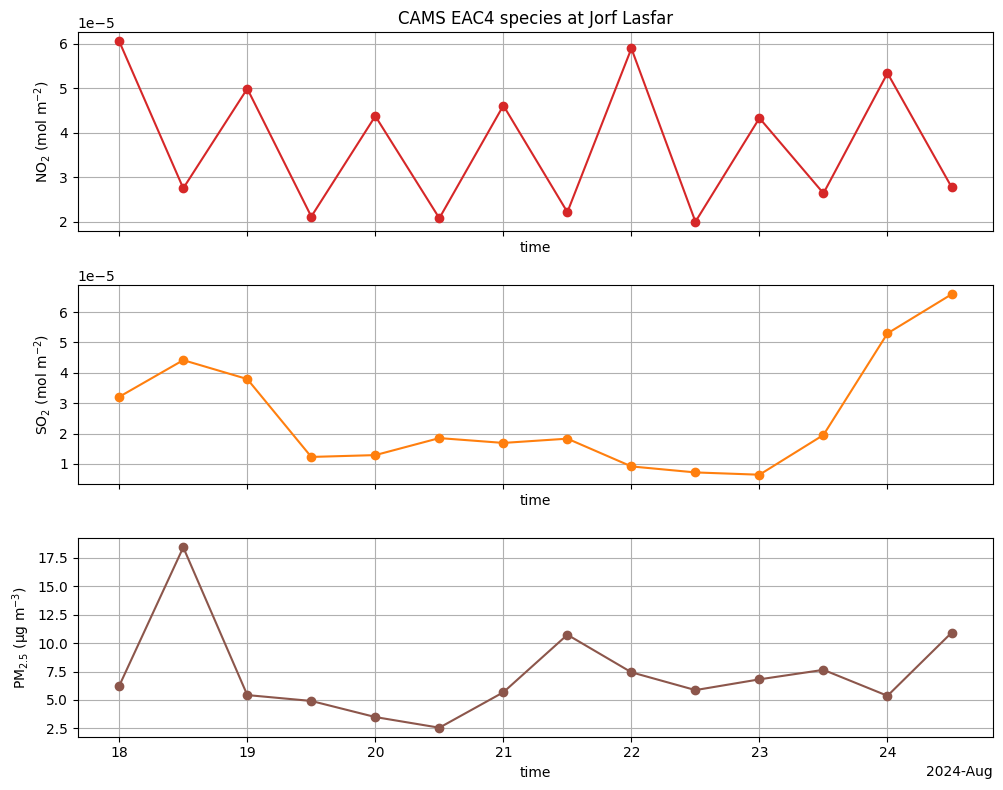

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

no2_ts.plot(ax=axes[0], marker='o', color='tab:red')
axes[0].set_ylabel(f"NO$_2$ ({species_units['NO2']})")
axes[0].set_title('')
axes[0].grid(True)

so2_ts.plot(ax=axes[1], marker='o', color='tab:orange')
axes[1].set_ylabel(f"SO$_2$ ({species_units['SO2']})")
axes[1].set_title('')
axes[1].grid(True)

pm25_ts.plot(ax=axes[2], marker='o', color='tab:brown')
axes[2].set_ylabel(f"PM$_{{2.5}}$ ({species_units['PM2.5']})")
axes[2].set_title('')
axes[2].grid(True)

axes[0].set_title('CAMS EAC4 species at Jorf Lasfar')
plt.tight_layout()
plt.savefig(f'{DATADIR}/cams_species_timeseries_jorf_lasfar.png')

## Maps around Jorf Lasfar

### Define a function to plot a map

As we will create several maps, creating a function to do this reduces the amount of boilerplate
code, i.e. repeated copies of the same block of code. The function also marks the location of the
Jorf Lasfar industrial complex.

In [13]:
def create_figure(extent):
    # Create a map figure with coastlines, gridlines and the Jorf Lasfar marker
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(draw_labels=True, linestyle='--')
    ax.plot(jorf_lasfar_lon, jorf_lasfar_lat, marker='*', markersize=16,
            color='black', transform=ccrs.PlateCarree())
    ax.text(jorf_lasfar_lon + 0.3, jorf_lasfar_lat + 0.1, 'Jorf Lasfar',
            transform=ccrs.PlateCarree(), fontsize=11, fontweight='bold')
    return fig, ax

# Map extent: [west, east, south, north]
map_extent = [area[1], area[3], area[2], area[0]]

### Select date/time to map

We select a timestamp within the requested period to visualise the spatial distribution of each
species.

In [14]:
map_time = '2024-08-21T12:00:00'
map_time

'2024-08-21T12:00:00'

### Map of total column NO$_2$

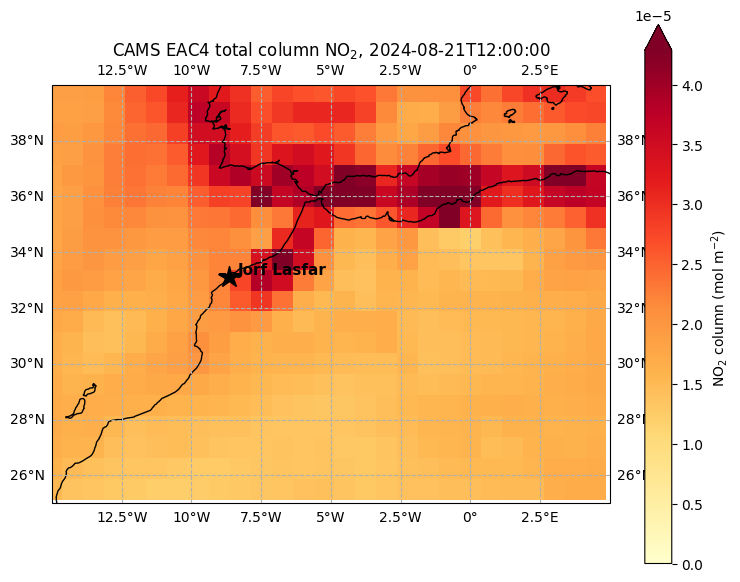

In [15]:
da = species['NO2'].sel(valid_time=map_time)
vmax = float(da.quantile(0.98))

_, ax = create_figure(map_extent)
da.plot.pcolormesh(ax=ax, x='longitude', y='latitude', add_colorbar=True, cmap='YlOrRd',
                    vmin=0, vmax=vmax, cbar_kwargs={'label': f"NO$_2$ column ({species_units['NO2']})"})
plt.title(f'CAMS EAC4 total column NO$_2$, {map_time}', fontsize=12)
plt.savefig(f'{DATADIR}/cams_no2_map_jorf_lasfar.png')

### Map of total column SO$_2$

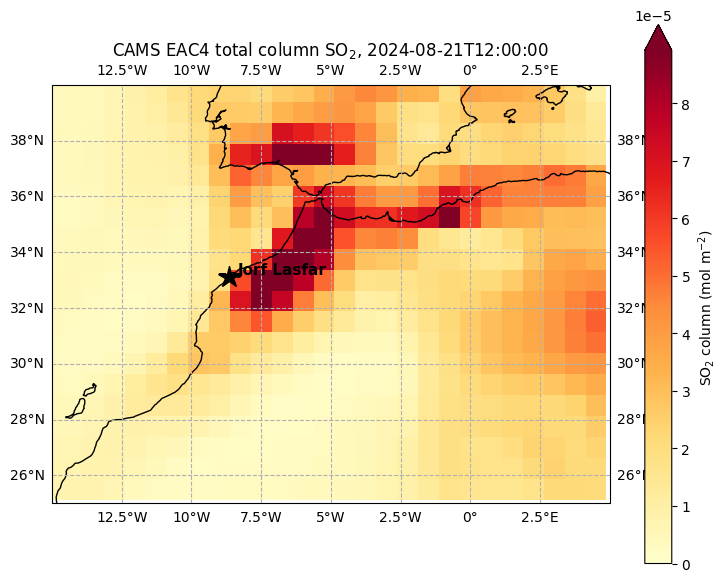

In [16]:
da = species['SO2'].sel(valid_time=map_time)
vmax = float(da.quantile(0.98))

_, ax = create_figure(map_extent)
da.plot.pcolormesh(ax=ax, x='longitude', y='latitude', add_colorbar=True, cmap='YlOrRd',
                    vmin=0, vmax=vmax, cbar_kwargs={'label': f"SO$_2$ column ({species_units['SO2']})"})
plt.title(f'CAMS EAC4 total column SO$_2$, {map_time}', fontsize=12)
plt.savefig(f'{DATADIR}/cams_so2_map_jorf_lasfar.png')

### Map of surface PM$_{2.5}$

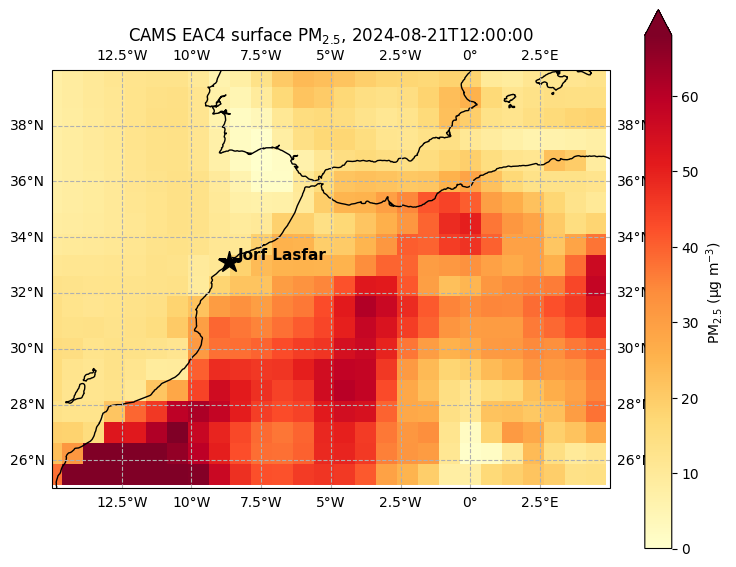

In [17]:
da = species['PM2.5'].sel(valid_time=map_time)
vmax = float(da.quantile(0.98))

_, ax = create_figure(map_extent)
da.plot.pcolormesh(ax=ax, x='longitude', y='latitude', add_colorbar=True, cmap='YlOrRd',
                    vmin=0, vmax=vmax, cbar_kwargs={'label': f"PM$_{{2.5}}$ ({species_units['PM2.5']})"})
plt.title(f'CAMS EAC4 surface PM$_{{2.5}}$, {map_time}', fontsize=12)
plt.savefig(f'{DATADIR}/cams_pm25_map_jorf_lasfar.png')

## Relating CAMS model species to satellite observations

The total column NO$_2$ plotted above is expressed in mol m$^{-2}$, the same unit used for the
TROPOMI tropospheric NO$_2$ column in
[`TROPOMI_NO2_Jorf_Lasfar.ipynb`](../satellite/wildfire_chemicals/TROPOMI_NO2_Jorf_Lasfar.ipynb).
CAMS EAC4 is a coarse-resolution (~80 km) global reanalysis, so it will not resolve the narrow
industrial plume seen by TROPOMI (~7 km pixels), but it should reproduce the broader regional
enhancement and its day-to-day variability. Comparing the two is a good way to understand the
difference between a global atmospheric composition model and high-resolution satellite retrievals.

## Suggested further steps

- Extend the `date` range to compute a multi-year climatology for NO$_2$ and SO$_2$ over Jorf Lasfar,
  similar to the dust AOD climatology calculated in `cams-global-reanalysis.ipynb`.
- Download CAMS wind components (`10m_u_component_of_wind`, `10m_v_component_of_wind`) to confirm the
  plume transport direction seen in the maps above.
- Compare weekday vs. weekend values to separate industrial emissions from traffic-related NO$_2$.
- Repeat this notebook for another CAMS species, such as `total_column_carbon_monoxide` or
  `total_column_ozone`.